# Production 2D FEP Subtraction — Clean Rebuild
### SSA — Diamond I11 Beamline

**This replaces the exploratory `Production_Subtraction.ipynb`** built during live debugging. That version proved the method; this one is the reusable tool, per `FEP_Subtraction_Project_Plan.docx` Section 9.

**Confirmed fixed conditions (do not change per crystal system):** 100mm distance, Swish technique, radially-binned scale fitting as the default correction method (a single global scale factor was proven insufficient — see Trial 1 and this pipeline's own validation history).

**Parameterised per crystal system (change these, nothing else, for a new system):** `CRYSTAL_SAMPLE_CODE` and `BACKGROUND_SAMPLE_CODES` in Step 0.

**What this notebook does NOT assume:** which background wins, or what QC thresholds are appropriate — both are re-validated fresh in Step 5 for whatever crystal system is configured, never carried over from a previous system.

---
**Run cells one at a time, top to bottom.**

---
## Step 0 — Paths, geometry, and per-system parameters

In [1]:
import os, glob
import numpy as np
import pandas as pd
from scipy import ndimage

# ══════════════════════════════════════════════════════════════
# PATHS — confirm/update before running
# ══════════════════════════════════════════════════════════════

MODULE_DIR   = r"C:/Users/ezxsa27/I11_PXRD_SSA/I11_PXRD_processing_scripts/FEP_Subtraction/"
import sys
sys.path.insert(0, MODULE_DIR)

RAW_ROOT     = r"E:/static/raw/raw_D1+2"
OUTPUT_DIR   = r"E:/static/Corrected_2D/Production_100mm_Swish/"
TRACKER_PATH = r"C:/Users/ezxsa27/OneDrive - The University of Nottingham/Nottingham/Year 3 (June 26 -)/Static Trials/I11_Static_Trials_Tracker_CLEAN.xlsx"

PONI_100MM = r"E:/static/raw/Calib/Calib_100.poni"
MASK_100MM_BASE = r"E:/static/raw/Calib/Calib_100_mask.npy"   # original mask, BEFORE artifact scan

# ══════════════════════════════════════════════════════════════
# PER-CRYSTAL-SYSTEM PARAMETERS — change ONLY these for a new system
# ══════════════════════════════════════════════════════════════
DISTANCE_MM          = 100
EXPOSURE_CODE         = "Swish"
CRYSTAL_SAMPLE_CODE   = "Gly_AS_tri"
BACKGROUND_SAMPLE_CODES = ["Water_tri", "EtOH_tri"]   # candidates to validate, not assumed winners

os.makedirs(OUTPUT_DIR, exist_ok=True)

tracker = pd.read_excel(TRACKER_PATH, sheet_name="Condition Tracker", header=6)
tracker.columns = [str(c).strip() for c in tracker.columns]
tracker["Sample code"]   = tracker["Sample code"].astype(str).str.strip()
tracker["Exposure code"] = tracker["Exposure code"].astype(str).str.strip()
tracker["Data logged?"]  = tracker["Data logged?"].astype(str).str.strip().str.upper()

tracker_clean = tracker[
    (tracker["Data logged?"] == "Y") &
    (tracker["Exclude?"].isna())
]

def collection_numbers_for(sample_code, distance=DISTANCE_MM, exposure_code=EXPOSURE_CODE):
    sub = tracker_clean[
        (tracker_clean["Sample code"] == sample_code) &
        (tracker_clean["Distance (mm)"] == distance)
    ]
    if exposure_code is not None:
        sub = sub[sub["Exposure code"] == exposure_code]
    return sub["Collection #(s)"].dropna().astype(int).astype(str).tolist()

def extract_number(fp):
    stem = os.path.splitext(os.path.basename(fp))[0]
    for part in reversed(stem.replace("-", "_").split("_")):
        if part.isdigit():
            return part
    return ""

all_raw_files = sorted(glob.glob(os.path.join(RAW_ROOT, "*.nxs")))
all_numbers = {f: extract_number(f) for f in all_raw_files}

def files_for_numbers(numbers):
    wanted = set(numbers)
    return sorted([f for f, n in all_numbers.items() if n in wanted])

CRYSTAL_FILES = files_for_numbers(collection_numbers_for(CRYSTAL_SAMPLE_CODE))
BACKGROUND_FILES = {
    code: files_for_numbers(collection_numbers_for(code))
    for code in BACKGROUND_SAMPLE_CODES
}

print(f"Raw files found: {len(all_raw_files)}")
print(f"{CRYSTAL_SAMPLE_CODE} @ {DISTANCE_MM}mm/{EXPOSURE_CODE}: {len(CRYSTAL_FILES)} files")
for code, files in BACKGROUND_FILES.items():
    print(f"{code} @ {DISTANCE_MM}mm/{EXPOSURE_CODE}: {len(files)} files")

Raw files found: 199
Gly_AS_tri @ 100mm/Swish: 4 files
Water_tri @ 100mm/Swish: 4 files
EtOH_tri @ 100mm/Swish: 4 files


In [2]:
from fep_subtraction_2d_i11 import (
    beam_center_px_from_poni,
    FrameMetricConfig,
    evaluate_frame_with_status,
    classify_dataset,
    _load_pixium_frame,
    _mad_sigma,
)

cy, cx = beam_center_px_from_poni(PONI_100MM)
mask_base = np.load(MASK_100MM_BASE)
print(f"Geometry: beam centre row={cy:.2f} col={cx:.2f} ({mask_base.shape})")

cfg_probe = FrameMetricConfig(beam_center_px=(cy, cx), detect_fep_ring=True)
print("✅ Geometry loaded. Ready for Step 1.")

Geometry: beam centre row=1442.65 col=1441.74 ((2881, 2880))
✅ Geometry loaded. Ready for Step 1.


---
## Step 1 — FEP ring radius

Auto-detected fresh for this geometry, not assumed from a different distance/session.

In [3]:
probe_fp = list(BACKGROUND_FILES.values())[0][0] if any(BACKGROUND_FILES.values()) else CRYSTAL_FILES[0]
metrics, status = evaluate_frame_with_status(probe_fp, mask=mask_base, config=cfg_probe)
FEP_RING_R = status.fep_ring_r
print(f"Status: {status.status}")
print(f"FEP ring radius: {FEP_RING_R}px")

cfg = FrameMetricConfig(beam_center_px=(cy, cx), detect_fep_ring=False, fixed_fep_ring_r=FEP_RING_R)

Status: ok
FEP ring radius: 223px


---
## Step 2 — Fixed-pixel artifact detection (sensor property, not sample-dependent)

Scans EVERY available crystal-free background condition for pixels that are consistent outliers in ALL of them simultaneously — these cannot be genuine diffraction (which would only appear in crystal-containing frames), so they're almost certainly hot/dead detector pixels. Run once per geometry; result is reusable for any crystal system at this same distance.

In [4]:
def load_averaged(filepaths):
    frames = []
    for fp in filepaths:
        f = _load_pixium_frame(fp)
        if f.ndim == 3:
            f = f.mean(axis=0)
        frames.append(f)
    return np.mean(frames, axis=0)

def residual_map(arr, cy, cx):
    rows, cols = arr.shape
    y_idx, x_idx = np.ogrid[:rows, :cols]
    r_map = np.sqrt((x_idx - cx) ** 2 + (y_idx - cy) ** 2).astype(np.int32)
    r_max = int(r_map.max())
    radial_sum = np.bincount(r_map.ravel(), weights=arr.ravel(), minlength=r_max + 1)
    radial_cnt = np.bincount(r_map.ravel(), minlength=r_max + 1)
    with np.errstate(invalid="ignore", divide="ignore"):
        radial_mean = np.where(radial_cnt > 0, radial_sum / radial_cnt, 0.0)
    return arr - radial_mean[r_map]

valid_mask_base = ~mask_base.astype(bool)
condition_averages = {code: load_averaged(files) for code, files in BACKGROUND_FILES.items() if files}
residuals = {code: residual_map(avg, cy, cx) for code, avg in condition_averages.items()}
sigmas = {code: _mad_sigma(res[valid_mask_base]) for code, res in residuals.items()}

artifact_mask = np.ones_like(mask_base, dtype=bool)
for code, res in residuals.items():
    artifact_mask &= (res > 8 * sigmas[code])
artifact_mask &= valid_mask_base

n_artifacts = int(artifact_mask.sum())
print(f"Suspected fixed-pixel artifacts (outlier in ALL {len(condition_averages)} conditions): {n_artifacts}")

mask = mask_base.copy()
mask[artifact_mask] = True
MASK_PATH_FINAL = os.path.join(OUTPUT_DIR, f"mask_{DISTANCE_MM}mm_artifacts_added.npy")
np.save(MASK_PATH_FINAL, mask)
print(f"Total masked pixels: {mask.sum()} (was {mask_base.sum()})")
print(f"Saved: {MASK_PATH_FINAL}")

valid_mask = ~mask.astype(bool)

Suspected fixed-pixel artifacts (outlier in ALL 2 conditions): 9612
Total masked pixels: 64310 (was 54698)
Saved: E:/static/Corrected_2D/Production_100mm_Swish/mask_100mm_artifacts_added.npy


---
## Step 3 — Build background candidates

Generic over `BACKGROUND_SAMPLE_CODES` — works unchanged for any crystal system's own trisegment conditions.

In [5]:
def average_frames(filepaths):
    stack = []
    for fp in filepaths:
        frame = _load_pixium_frame(fp)
        if frame.ndim == 3:
            frame = frame.mean(axis=0)
        stack.append(frame.astype(np.float64))
    return np.mean(stack, axis=0)

backgrounds = {}
for code, files in BACKGROUND_FILES.items():
    if not files:
        print(f"⚠️  No files for {code} — skipping")
        continue
    backgrounds[code] = average_frames(files)
    print(f"{code}: {len(files)} frames averaged (noise / \u221an = {1/np.sqrt(len(files)):.3f})")

print(f"\n✅ {len(backgrounds)} background candidate(s) built.")

Water_tri: 4 frames averaged (noise / √n = 0.500)
EtOH_tri: 4 frames averaged (noise / √n = 0.500)

✅ 2 background candidate(s) built.


---
## Step 4 — Classify crystal-sample frames

Identifies confirmed crystal-positive frames from `CRYSTAL_SAMPLE_CODE` — the set the background candidates will be validated against, and the set the production pass runs on.

In [6]:
csv_path = os.path.join(OUTPUT_DIR, f"{CRYSTAL_SAMPLE_CODE}_{DISTANCE_MM}mm_classification.csv")

crystal_metrics = classify_dataset(CRYSTAL_FILES, mask=mask, config=cfg, csv_output=csv_path)
crystal_frames = [m for m in crystal_metrics if m.auto_class == "crystal"]

print(f"\n{len(crystal_frames)} confirmed crystal frame(s) out of {len(crystal_metrics)} total:")
for m in crystal_frames:
    print(f"  {os.path.basename(m.filepath)}  score={m.crystal_score:.3f}")


────────────────────────────────────────────────────────────────
  Dataset classification  (4 frames from 4 files)
────────────────────────────────────────────────────────────────
  crystal         4 frames  ████████████████████████████████████████
  solution        0 frames  
  gas             0 frames  
  uncertain       0 frames  
────────────────────────────────────────────────────────────────

  Top crystal candidates:
    score=1.000  i11-1-145413.nxs  frame=0
    score=1.000  i11-1-145414.nxs  frame=0
    score=1.000  i11-1-145415.nxs  frame=0
    score=1.000  i11-1-145416.nxs  frame=0

  ML training CSV: E:/static/Corrected_2D/Production_100mm_Swish/Gly_AS_tri_100mm_classification.csv


4 confirmed crystal frame(s) out of 4 total:
  i11-1-145413.nxs  score=1.000
  i11-1-145414.nxs  score=1.000
  i11-1-145415.nxs  score=1.000
  i11-1-145416.nxs  score=1.000


---
## Step 5 — Background validation (radially-binned, both diffuse AND ring regions)

**Default correction method: radially-binned scale fitting**, not a single global scale — proven necessary, since a global scale reliably satisfies the diffuse region (dominated by pixel count) while leaving the FEP ring itself under-subtracted, invisibly to a diffuse-only check.

Every background candidate is checked against EVERY confirmed crystal frame, on BOTH the diffuse region and the ring region — not assumed from a previous crystal system or a single test frame.

In [7]:
def radial_bestfit_correct(raw, bg, valid_mask, r_map, bin_width=40):
    """Fit an independent best-fit scale per radial annulus. Returns
    the corrected frame AND the per-bin scale map, so the ring bin's
    actual fitted scale can be inspected/audited."""
    r_max = int(r_map.max())
    bins = np.arange(0, r_max + bin_width, bin_width)
    corrected = raw.copy()
    bin_scales = {}
    for lo, hi in zip(bins[:-1], bins[1:]):
        bin_mask = (r_map >= lo) & (r_map < hi) & valid_mask
        if bin_mask.sum() < 50:
            continue
        r_vals, b_vals = raw[bin_mask], bg[bin_mask]
        denom = np.sum(b_vals * b_vals)
        s = float(np.sum(r_vals * b_vals) / denom) if denom > 0 else 1.0
        corrected[bin_mask] = raw[bin_mask] - s * bg[bin_mask]
        bin_scales[(lo, hi)] = s
    return corrected, bin_scales

def bias_check(corrected, region_mask):
    vals = corrected[region_mask]
    med = np.median(vals)
    sigma = _mad_sigma(vals)
    return med / sigma if sigma > 0 else float("nan")

rows, cols = mask.shape
y_idx, x_idx = np.ogrid[:rows, :cols]
r_map_full = np.sqrt((x_idx - cx) ** 2 + (y_idx - cy) ** 2).astype(np.int32)
diffuse_mask = (r_map_full >= 400) & (r_map_full <= 1200) & valid_mask
ring_mask = (r_map_full >= FEP_RING_R - 15) & (r_map_full <= FEP_RING_R + 15) & valid_mask

validation_results = []
for m in crystal_frames:
    raw = _load_pixium_frame(m.filepath, m.frame_index)
    if raw.ndim == 3:
        raw = raw[m.frame_index]
    for bg_name, bg_array in backgrounds.items():
        corrected, bin_scales = radial_bestfit_correct(raw, bg_array, valid_mask, r_map_full)
        diffuse_bias = bias_check(corrected, diffuse_mask)
        ring_bias = bias_check(corrected, ring_mask)
        validation_results.append({
            "file": os.path.basename(m.filepath), "background": bg_name,
            "diffuse_bias": diffuse_bias, "ring_bias": ring_bias,
        })

df_validation = pd.DataFrame(validation_results)
summary_validation = df_validation.groupby("background")[["diffuse_bias", "ring_bias"]].agg(["mean", "std"])
print(summary_validation)

print("\nPer-frame detail:")
print(df_validation.to_string(index=False))

           diffuse_bias           ring_bias          
                   mean       std      mean       std
background                                           
EtOH_tri       0.035528  0.011881 -0.099307  0.044688
Water_tri      0.010095  0.014827  0.297611  0.198914

Per-frame detail:
            file background  diffuse_bias  ring_bias
i11-1-145413.nxs  Water_tri      0.002739   0.086055
i11-1-145413.nxs   EtOH_tri      0.030888  -0.119088
i11-1-145414.nxs  Water_tri      0.032122   0.336298
i11-1-145414.nxs   EtOH_tri      0.053012  -0.032765
i11-1-145415.nxs  Water_tri      0.000250   0.214477
i11-1-145415.nxs   EtOH_tri      0.026483  -0.116413
i11-1-145416.nxs  Water_tri      0.005270   0.553613
i11-1-145416.nxs   EtOH_tri      0.031730  -0.128961


---
## Step 5b — Pick the winning background

Based on Step 5's output — update `WINNING_BACKGROUND` to whichever candidate shows the smallest mean |bias| on BOTH diffuse and ring regions across all confirmed frames. Not assumed from a different crystal system.

In [8]:
# ══════════════════════════════════════════════════════════════
# Set based on Step 5's printed summary — do not carry over from
# a different crystal system without re-checking.
# ══════════════════════════════════════════════════════════════
WINNING_BACKGROUND = "Water_tri"   # <-- update based on Step 5 output

print(f"Using background: {WINNING_BACKGROUND}")
winning_bg_array = backgrounds[WINNING_BACKGROUND]

Using background: Water_tri


---
## Step 6 — Production batch: radially-binned subtraction + automated QC

Applies the winning background to every confirmed crystal frame using radially-binned scaling, then runs automated QC (diffuse bias, ring bias) on the RESULT — no manual per-frame inspection required. Frames failing either check are flagged REVIEW, not silently included.

In [9]:
BIAS_THRESHOLD = 1.0   # |median/sigma| above this on EITHER region triggers REVIEW

production_results = []
prod_dir = os.path.join(OUTPUT_DIR, "production")
os.makedirs(prod_dir, exist_ok=True)

for m in crystal_frames:
    fp = m.filepath
    raw = _load_pixium_frame(fp, m.frame_index)
    if raw.ndim == 3:
        raw = raw[m.frame_index]

    corrected, bin_scales = radial_bestfit_correct(raw, winning_bg_array, valid_mask, r_map_full)
    corrected_clipped = np.clip(corrected, 0.0, None)

    diffuse_bias = bias_check(corrected, diffuse_mask)
    ring_bias = bias_check(corrected, ring_mask)

    flags = []
    if abs(diffuse_bias) > BIAS_THRESHOLD:
        flags.append(f"diffuse_bias({diffuse_bias:.2f})")
    if abs(ring_bias) > BIAS_THRESHOLD:
        flags.append(f"ring_bias({ring_bias:.2f})")
    verdict = "PASS" if not flags else "REVIEW"

    out_path = os.path.join(prod_dir, f"{os.path.splitext(os.path.basename(fp))[0]}_bg_{WINNING_BACKGROUND}.npy")
    np.save(out_path, corrected_clipped)

    production_results.append({
        "file": os.path.basename(fp), "background": WINNING_BACKGROUND,
        "diffuse_bias": diffuse_bias, "ring_bias": ring_bias,
        "verdict": verdict, "flags": "; ".join(flags), "output": out_path,
    })
    print(f"  {os.path.basename(fp)}: {verdict}" + (f" ({'; '.join(flags)})" if flags else ""))

df_production = pd.DataFrame(production_results)
df_production.to_csv(os.path.join(OUTPUT_DIR, "production_run_summary.csv"), index=False)

n_pass = (df_production["verdict"] == "PASS").sum()
print(f"\n✅ Production pass complete: {len(df_production)} frames, {n_pass} PASS, {len(df_production)-n_pass} REVIEW")
print(df_production[["file", "diffuse_bias", "ring_bias", "verdict"]].to_string(index=False))

  i11-1-145413.nxs: PASS
  i11-1-145414.nxs: PASS
  i11-1-145415.nxs: PASS
  i11-1-145416.nxs: PASS

✅ Production pass complete: 4 frames, 4 PASS, 0 REVIEW
            file  diffuse_bias  ring_bias verdict
i11-1-145413.nxs      0.002739   0.086055    PASS
i11-1-145414.nxs      0.032122   0.336298    PASS
i11-1-145415.nxs      0.000250   0.214477    PASS
i11-1-145416.nxs      0.005270   0.553613    PASS


In [10]:
from pathlib import Path
from fep_subtraction_2d_i11 import _write_corrected_nexus
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

BIAS_THRESHOLD = 1.0

production_results = []
prod_dir = os.path.join(OUTPUT_DIR, "production")
os.makedirs(prod_dir, exist_ok=True)

for m in crystal_frames:
    fp = m.filepath
    raw = _load_pixium_frame(fp, m.frame_index)
    if raw.ndim == 3:
        raw = raw[m.frame_index]

    corrected, bin_scales = radial_bestfit_correct(raw, winning_bg_array, valid_mask, r_map_full)
    corrected_clipped = np.clip(corrected, 0.0, None)

    diffuse_bias = bias_check(corrected, diffuse_mask)
    ring_bias = bias_check(corrected, ring_mask)
    flags = []
    if abs(diffuse_bias) > BIAS_THRESHOLD:
        flags.append(f"diffuse_bias({diffuse_bias:.2f})")
    if abs(ring_bias) > BIAS_THRESHOLD:
        flags.append(f"ring_bias({ring_bias:.2f})")
    verdict = "PASS" if not flags else "REVIEW"

    stem = os.path.splitext(os.path.basename(fp))[0]

    # Output 1: corrected frame as NeXus — this is what feeds baselining/integration
    nxs_out_path = os.path.join(prod_dir, f"{stem}_corrected.nxs")
    _write_corrected_nexus(
        corrected=corrected_clipped,
        source_filepath=Path(fp),
        output_filepath=Path(nxs_out_path),
        output_detector_path="entry1/pixium_hdf/data",
        scale_factor=1.0,   # radially-binned: no single scale value applies; per-bin scales in bin_scales if needed
        background_type=WINNING_BACKGROUND,
        n_background_frames=len(BACKGROUND_FILES[WINNING_BACKGROUND]),
        clip_negative=True,
    )

    # Output 2: visual PNG, raw vs corrected, for direct visual inspection
    png_out_path = os.path.join(prod_dir, f"{stem}_comparison.png")
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    vmin = max(1, np.percentile(raw[raw > 0], 1))
    axes[0].imshow(raw, origin="lower", norm=LogNorm(vmin=vmin, vmax=raw.max()), cmap="viridis")
    axes[0].set_title(f"Raw — {os.path.basename(fp)}")
    vmin_c = max(0.1, np.percentile(corrected_clipped[corrected_clipped > 0], 1)) if (corrected_clipped > 0).any() else 0.1
    axes[1].imshow(corrected_clipped, origin="lower", norm=LogNorm(vmin=vmin_c, vmax=max(corrected_clipped.max(), 1)), cmap="viridis")
    axes[1].set_title(f"Corrected ({WINNING_BACKGROUND}) — {verdict}")
    plt.tight_layout()
    plt.savefig(png_out_path, dpi=150)
    plt.close(fig)

    production_results.append({
        "file": os.path.basename(fp), "background": WINNING_BACKGROUND,
        "diffuse_bias": diffuse_bias, "ring_bias": ring_bias,
        "verdict": verdict, "flags": "; ".join(flags),
        "nexus_output": nxs_out_path, "png_output": png_out_path,
    })
    print(f"  {os.path.basename(fp)}: {verdict}" + (f" ({'; '.join(flags)})" if flags else ""))

df_production = pd.DataFrame(production_results)
df_production.to_csv(os.path.join(OUTPUT_DIR, "production_run_summary.csv"), index=False)

n_pass = (df_production["verdict"] == "PASS").sum()
print(f"\n✅ Production pass complete: {len(df_production)} frames, {n_pass} PASS, {len(df_production)-n_pass} REVIEW")
print(df_production[["file", "diffuse_bias", "ring_bias", "verdict"]].to_string(index=False))

  i11-1-145413.nxs: PASS
  i11-1-145414.nxs: PASS
  i11-1-145415.nxs: PASS
  i11-1-145416.nxs: PASS

✅ Production pass complete: 4 frames, 4 PASS, 0 REVIEW
            file  diffuse_bias  ring_bias verdict
i11-1-145413.nxs      0.002739   0.086055    PASS
i11-1-145414.nxs      0.032122   0.336298    PASS
i11-1-145415.nxs      0.000250   0.214477    PASS
i11-1-145416.nxs      0.005270   0.553613    PASS


In [14]:
from pathlib import Path
from fep_subtraction_2d_i11 import _write_corrected_nexus
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

BIAS_THRESHOLD = 1.0
SPOT_SIGMA_MULTIPLIER = 5.0   # consistent with classifier's default sigma_multiplier

# ── Display-only controls for panel c) ─────────────────────────────
# These affect ONLY how spots are rendered in the PNG. They do not
# touch spot_pixel_count/spot_density_final (still computed from the
# unmodified spot_mask below) or the NeXus output.
SPOT_DISPLAY_MODE = "binary"   # "binary" = uniform brightness per detected pixel
                                # "intensity" = original percentile-scaled grayscale
SPOT_DILATION_PX = 2           # grow each detected pixel by N px so single hits
                                # are visible at full-frame display scale; 0 = off

production_results = []
prod_dir = os.path.join(OUTPUT_DIR, "production")
os.makedirs(prod_dir, exist_ok=True)

for m in crystal_frames:
    fp = m.filepath
    raw = _load_pixium_frame(fp, m.frame_index)
    if raw.ndim == 3:
        raw = raw[m.frame_index]

    corrected, bin_scales = radial_bestfit_correct(raw, winning_bg_array, valid_mask, r_map_full)
    corrected_clipped = np.clip(corrected, 0.0, None)

    diffuse_bias = bias_check(corrected, diffuse_mask)
    ring_bias = bias_check(corrected, ring_mask)
    flags = []
    if abs(diffuse_bias) > BIAS_THRESHOLD:
        flags.append(f"diffuse_bias({diffuse_bias:.2f})")
    if abs(ring_bias) > BIAS_THRESHOLD:
        flags.append(f"ring_bias({ring_bias:.2f})")
    verdict = "PASS" if not flags else "REVIEW"

    stem = os.path.splitext(os.path.basename(fp))[0]

    # ── Spot detection (unchanged — this is the metric of record) ──
    noise_sigma_diffuse = _mad_sigma(corrected[diffuse_mask])
    spot_display_threshold = SPOT_SIGMA_MULTIPLIER * noise_sigma_diffuse
    spot_mask = (corrected_clipped > spot_display_threshold) & valid_mask
    spot_pixel_count = int(spot_mask.sum())
    spot_density_final = spot_pixel_count / int(valid_mask.sum())

    # ── Spot rendering (display only) ───────────────────────────────
    display_mask = spot_mask
    if SPOT_DILATION_PX > 0:
        display_mask = ndimage.binary_dilation(spot_mask, iterations=SPOT_DILATION_PX)
        display_mask &= valid_mask   # never grow spots into masked regions

    if SPOT_DISPLAY_MODE == "binary":
        spots_display = np.where(display_mask, 1.0, 0.0)
        spots_vmin, spots_vmax = 0.0, 1.0
    else:  # "intensity"
        spots_display = np.where(display_mask, corrected_clipped, 0.0)
        spot_vals = spots_display[spots_display > 0]
        spots_vmin = 0.0
        spots_vmax = float(np.percentile(spot_vals, 99.5)) if spot_vals.size > 0 else 1.0

    # Output 1: corrected frame as NeXus — unchanged, this is what feeds
    # baselining/integration/diffraction sorting downstream
    nxs_out_path = os.path.join(prod_dir, f"{stem}_corrected.nxs")
    _write_corrected_nexus(
        corrected=corrected_clipped,
        source_filepath=Path(fp),
        output_filepath=Path(nxs_out_path),
        output_detector_path="entry1/pixium_hdf/data",
        scale_factor=1.0,   # radially-binned: no single scale value applies; per-bin scales in bin_scales if needed
        background_type=WINNING_BACKGROUND,
        n_background_frames=len(BACKGROUND_FILES[WINNING_BACKGROUND]),
        clip_negative=True,
    )

    # Output 2: visual PNG — raw | corrected | spots-only, for QC inspection
    png_out_path = os.path.join(prod_dir, f"{stem}_comparison.png")
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    vmin = max(1, np.percentile(raw[raw > 0], 1))
    axes[0].imshow(raw, origin="lower", norm=LogNorm(vmin=vmin, vmax=raw.max()), cmap="viridis")
    axes[0].set_title(f"a) Raw — {os.path.basename(fp)}")

    vmin_c = max(0.1, np.percentile(corrected_clipped[corrected_clipped > 0], 1)) if (corrected_clipped > 0).any() else 0.1
    axes[1].imshow(corrected_clipped, origin="lower", norm=LogNorm(vmin=vmin_c, vmax=max(corrected_clipped.max(), 1)), cmap="viridis")
    axes[1].set_title(f"b) Corrected ({WINNING_BACKGROUND}) — {verdict}")

    axes[2].imshow(spots_display, origin="lower", cmap="gray", vmin=spots_vmin, vmax=spots_vmax)
    axes[2].set_facecolor("black")
    axes[2].set_title(f"c) Spots only (>{SPOT_SIGMA_MULTIPLIER:.0f}\u03c3, n={spot_pixel_count}, dilated {SPOT_DILATION_PX}px)")

    plt.tight_layout()
    plt.savefig(png_out_path, dpi=150)
    plt.close(fig)

    production_results.append({
        "file": os.path.basename(fp), "background": WINNING_BACKGROUND,
        "diffuse_bias": diffuse_bias, "ring_bias": ring_bias,
        "spot_pixel_count": spot_pixel_count, "spot_density_final": spot_density_final,
        "verdict": verdict, "flags": "; ".join(flags),
        "nexus_output": nxs_out_path, "png_output": png_out_path,
    })
    print(f"  {os.path.basename(fp)}: {verdict}  spots={spot_pixel_count}" + (f" ({'; '.join(flags)})" if flags else ""))

df_production = pd.DataFrame(production_results)
df_production.to_csv(os.path.join(OUTPUT_DIR, "production_run_summary.csv"), index=False)

n_pass = (df_production["verdict"] == "PASS").sum()
print(f"\n✅ Production pass complete: {len(df_production)} frames, {n_pass} PASS, {len(df_production)-n_pass} REVIEW")
print(df_production[["file", "diffuse_bias", "ring_bias", "spot_pixel_count", "verdict"]].to_string(index=False))

  i11-1-145413.nxs: PASS  spots=2084
  i11-1-145414.nxs: PASS  spots=40492
  i11-1-145415.nxs: PASS  spots=2140
  i11-1-145416.nxs: PASS  spots=13871

✅ Production pass complete: 4 frames, 4 PASS, 0 REVIEW
            file  diffuse_bias  ring_bias  spot_pixel_count verdict
i11-1-145413.nxs      0.002739   0.086055              2084    PASS
i11-1-145414.nxs      0.032122   0.336298             40492    PASS
i11-1-145415.nxs      0.000250   0.214477              2140    PASS
i11-1-145416.nxs      0.005270   0.553613             13871    PASS


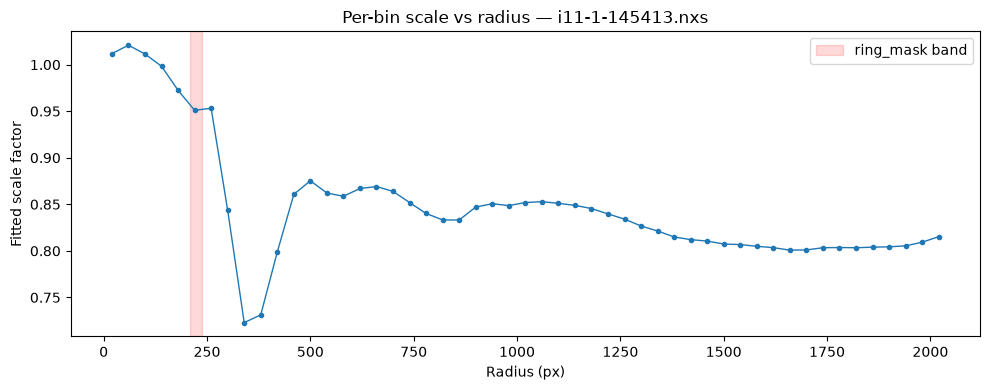

In [15]:
# Diagnostic: plot fitted scale vs radius for one frame, to see if it's
# noisy/discontinuous at the annuli overlapping the FEP ring band.
m = crystal_frames[0]  # pick the frame you want to inspect, e.g. 145414
raw = _load_pixium_frame(m.filepath, m.frame_index)
if raw.ndim == 3:
    raw = raw[m.frame_index]

_, bin_scales = radial_bestfit_correct(raw, winning_bg_array, valid_mask, r_map_full)
radii = [(lo + hi) / 2 for lo, hi in bin_scales]
scales = list(bin_scales.values())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(radii, scales, marker="o", ms=3, lw=1)
ax.axvspan(FEP_RING_R - 15, FEP_RING_R + 15, alpha=0.15, color="red", label="ring_mask band")
ax.set_xlabel("Radius (px)")
ax.set_ylabel("Fitted scale factor")
ax.set_title(f"Per-bin scale vs radius — {os.path.basename(m.filepath)}")
ax.legend()
plt.tight_layout()
plt.show()

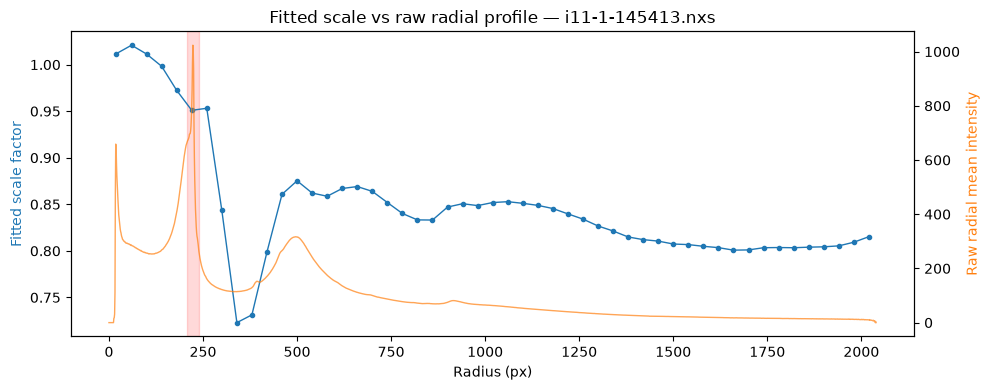

In [16]:
radial_sum = np.bincount(r_map_full[valid_mask].ravel(), weights=raw[valid_mask].ravel(),
                          minlength=int(r_map_full.max()) + 1)
radial_cnt = np.bincount(r_map_full[valid_mask].ravel(), minlength=int(r_map_full.max()) + 1)
with np.errstate(invalid="ignore", divide="ignore"):
    raw_radial_mean = np.where(radial_cnt > 0, radial_sum / radial_cnt, 0.0)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(radii, scales, marker="o", ms=3, lw=1, color="tab:blue")
ax1.set_xlabel("Radius (px)")
ax1.set_ylabel("Fitted scale factor", color="tab:blue")
ax1.axvspan(FEP_RING_R - 15, FEP_RING_R + 15, alpha=0.15, color="red", label="ring_mask band")

ax2 = ax1.twinx()
ax2.plot(raw_radial_mean[:2100], lw=1, color="tab:orange", alpha=0.7)
ax2.set_ylabel("Raw radial mean intensity", color="tab:orange")
ax1.set_title(f"Fitted scale vs raw radial profile — {os.path.basename(m.filepath)}")
plt.tight_layout()
plt.show()

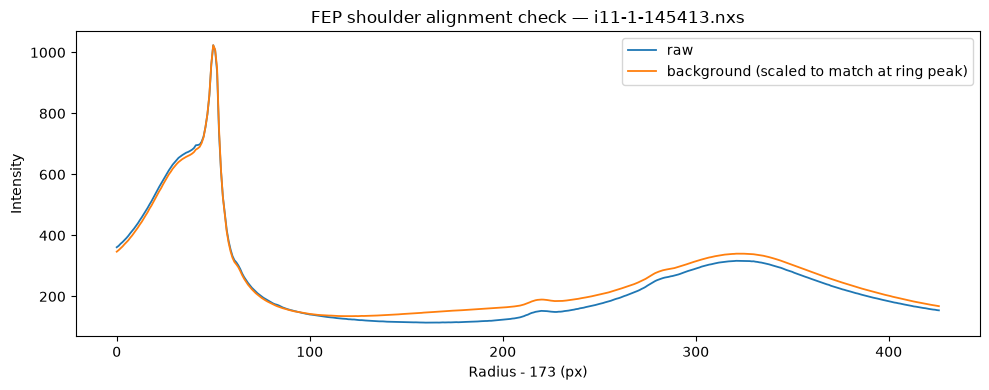

In [17]:
# Overlay raw vs background radial profiles (background scaled to raw's
# rough level) specifically over the FEP shoulder region, to check for
# a radial offset between the two curves rather than just a level mismatch.
bg_radial_sum = np.bincount(r_map_full[valid_mask].ravel(), weights=winning_bg_array[valid_mask].ravel(),
                             minlength=int(r_map_full.max()) + 1)
bg_radial_cnt = np.bincount(r_map_full[valid_mask].ravel(), minlength=int(r_map_full.max()) + 1)
with np.errstate(invalid="ignore", divide="ignore"):
    bg_radial_mean = np.where(bg_radial_cnt > 0, bg_radial_sum / bg_radial_cnt, 0.0)

lo, hi = FEP_RING_R - 50, 600
level_match = raw_radial_mean[FEP_RING_R] / bg_radial_mean[FEP_RING_R]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(raw_radial_mean[lo:hi], label="raw", lw=1.3)
ax.plot(bg_radial_mean[lo:hi] * level_match, label="background (scaled to match at ring peak)", lw=1.3)
ax.set_xlabel(f"Radius - {lo} (px)")
ax.set_ylabel("Intensity")
ax.set_title(f"FEP shoulder alignment check — {os.path.basename(m.filepath)}")
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 7 — Summary

In [12]:
print("=" * 60)
print("  PRODUCTION RUN SUMMARY")
print("=" * 60)
print(f"  Crystal system    : {CRYSTAL_SAMPLE_CODE}")
print(f"  Distance/technique: {DISTANCE_MM}mm / {EXPOSURE_CODE}")
print(f"  Background used   : {WINNING_BACKGROUND}")
print(f"  Correction method : radially-binned best-fit scale")
print(f"  Frames processed  : {len(df_production)}")
print(f"  PASS / REVIEW     : {n_pass} / {len(df_production)-n_pass}")
print(f"  Mask used         : {MASK_PATH_FINAL}")
print(f"  Output directory  : {prod_dir}")
print(f"  Summary CSV       : {os.path.join(OUTPUT_DIR, 'production_run_summary.csv')}")

if (df_production['verdict'] == 'REVIEW').any():
    print("\n⚠️  REVIEW frames — check individually before treating as final:")
    for _, row in df_production[df_production['verdict']=='REVIEW'].iterrows():
        print(f"    {row['file']}: {row['flags']}")

  PRODUCTION RUN SUMMARY
  Crystal system    : Gly_AS_tri
  Distance/technique: 100mm / Swish
  Background used   : Water_tri
  Correction method : radially-binned best-fit scale
  Frames processed  : 4
  PASS / REVIEW     : 4 / 0
  Mask used         : E:/static/Corrected_2D/Production_100mm_Swish/mask_100mm_artifacts_added.npy
  Output directory  : E:/static/Corrected_2D/Production_100mm_Swish/production
  Summary CSV       : E:/static/Corrected_2D/Production_100mm_Swish/production_run_summary.csv
